In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
print("Training images shape:", x_train.shape)   # (60000, 28, 28)
print("Training labels shape:", y_train.shape)   # (60000,)
print("Test images shape:", x_test.shape)        # (10000, 28, 28)
print("Test labels shape:", y_test.shape)        # (10000,)


Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


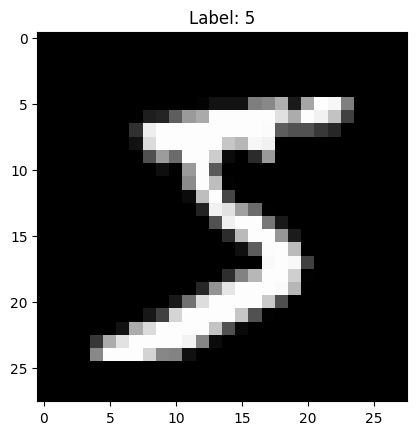

In [4]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [5]:
# Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the 28x28 images to 784-dimensional vectors
x_train = x_train.reshape((x_train.shape[0], -1))
x_test = x_test.reshape((x_test.shape[0], -1))


In [6]:

print("After flattening:")
print("x_train shape:", x_train.shape)   # (60000, 784)
print("x_test shape:", x_test.shape)     # (10000, 784)

After flattening:
x_train shape: (60000, 784)
x_test shape: (10000, 784)


In [7]:
model = keras.Sequential([
    layers.Input(shape=(784,)),            # input layer (flattened image)
    layers.Dense(128, activation='relu'),  # first hidden layer
    layers.Dense(64, activation='relu'),   # second hidden layer
    layers.Dense(10, activation='softmax') # output layer for 10 classes
])

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # because labels are integers 0-9
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,    # use 20% of training data for validation
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8952 - loss: 0.3689 - val_accuracy: 0.9483 - val_loss: 0.1812
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9547 - loss: 0.1537 - val_accuracy: 0.9620 - val_loss: 0.1291
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9674 - loss: 0.1079 - val_accuracy: 0.9679 - val_loss: 0.1119
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9760 - loss: 0.0800 - val_accuracy: 0.9700 - val_loss: 0.0954
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9823 - loss: 0.0613 - val_accuracy: 0.9707 - val_loss: 0.1022
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9849 - loss: 0.0505 - val_accuracy: 0.9737 - val_loss: 0.0920
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9876 - loss: 0.0408 - val_accuracy: 0.9755 - val_loss: 0.0867
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9898 - loss: 0.0338 - val_accuracy: 0

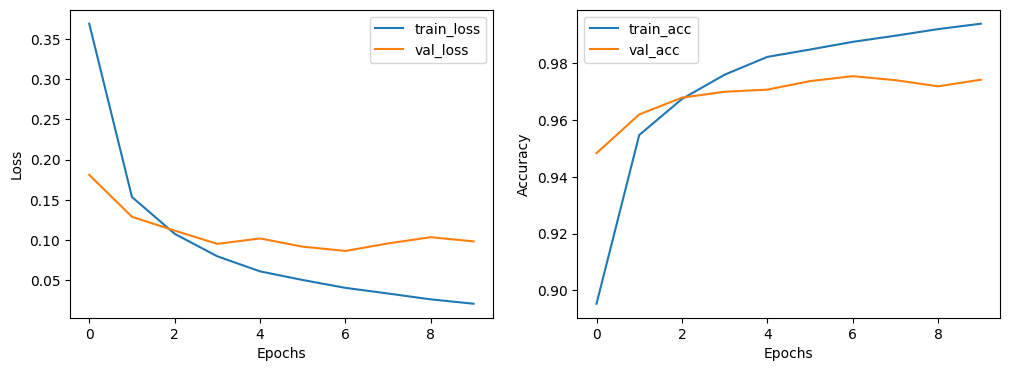

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [11]:
# Pick a test sample
index = 123
sample = x_test[index].reshape(1, 784)   # add batch dimension
pred = model.predict(sample, verbose=0)
predicted_class = np.argmax(pred)

print(f"True label: {y_test[index]}")
print(f"Predicted label: {predicted_class}")

True label: 6
Predicted label: 6


In [12]:
import os

In [14]:
def save_model(path="digit_recognizer.keras"):
    if os.path.exists(path):
        choice = input(f"Model already exists at '{path}'. Do you want to replace it? (y/n): ").strip().lower()
        if choice != "y":
            print("Model was not replaced.")
            return

    # Save the Keras model
    model.save(path)
    print(f"Model saved successfully as '{path}'.")
save_model()

Model saved successfully as 'digit_recognizer.keras'.
